# Assignment 5: Employee Attrition Prediction
### Decision Tree vs Random Forest Classification

**Dataset:** IBM HR Analytics Employee Attrition & Performance
(Kaggle: `pavansubhasht/ibm-hr-analytics-attrition-dataset`)

**Goal:** Predict whether an employee will leave the company (Attrition) using
demographic, professional, and work-related attributes, and compare a
Decision Tree Classifier against a Random Forest Classifier.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, classification_report
)

sns.set_style("whitegrid")
%matplotlib inline

## Download the dataset (via kagglehub)

In [2]:
import kagglehub
import os
import glob

# Download latest version
path = kagglehub.dataset_download("pavansubhasht/ibm-hr-analytics-attrition-dataset")
print("Path to dataset files:", path)

# Locate the CSV file inside the downloaded folder automatically
csv_candidates = glob.glob(os.path.join(path, "**", "*.csv"), recursive=True)
assert len(csv_candidates) > 0, "No CSV file found in the downloaded dataset folder."
DATA_PATH = csv_candidates[0]
print("Using CSV file:", DATA_PATH)

Using Colab cache for faster access to the 'ibm-hr-analytics-attrition-dataset' dataset.
Path to dataset files: /kaggle/input/ibm-hr-analytics-attrition-dataset
Using CSV file: /kaggle/input/ibm-hr-analytics-attrition-dataset/WA_Fn-UseC_-HR-Employee-Attrition.csv


## Task 1: Data Understanding (2 Marks)
- Load the dataset using Pandas
- Display the first five records
- Identify numerical features, categorical features, and the target variable
- Display dataset information and summary statistics

In [3]:
df = pd.read_csv(DATA_PATH)
print("Dataset shape:", df.shape)
df.head()

Dataset shape: (1470, 35)


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


In [4]:
target_variable = "Attrition"

numerical_features = df.select_dtypes(include=[np.number]).columns.tolist()
categorical_features = [
    col for col in df.columns
    if col not in numerical_features and col != target_variable
]

print(f"Target variable: {target_variable}\n")
print(f"Numerical features ({len(numerical_features)}):\n{numerical_features}\n")
print(f"Categorical features ({len(categorical_features)}):\n{categorical_features}")

Target variable: Attrition

Numerical features (26):
['Age', 'DailyRate', 'DistanceFromHome', 'Education', 'EmployeeCount', 'EmployeeNumber', 'EnvironmentSatisfaction', 'HourlyRate', 'JobInvolvement', 'JobLevel', 'JobSatisfaction', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction', 'StandardHours', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager']

Categorical features (8):
['BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole', 'MaritalStatus', 'Over18', 'OverTime']


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 14  JobLevel                

In [6]:
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Age,1470.0,NaN,NaN,NaN,36.92381,9.135373,18.0,30.0,36.0,43.0,60.0
Attrition,1470,2,No,1233,NaN,NaN,NaN,NaN,NaN,NaN,NaN
BusinessTravel,1470,3,Travel_Rarely,1043,NaN,NaN,NaN,NaN,NaN,NaN,NaN
DailyRate,1470.0,NaN,NaN,NaN,802.485714,403.5091,102.0,465.0,802.0,1157.0,1499.0
Department,1470,3,Research & Development,961,NaN,NaN,NaN,NaN,NaN,NaN,NaN
DistanceFromHome,1470.0,NaN,NaN,NaN,9.192517,8.106864,1.0,2.0,7.0,14.0,29.0
Education,1470.0,NaN,NaN,NaN,2.912925,1.024165,1.0,2.0,3.0,4.0,5.0
EducationField,1470,6,Life Sciences,606,NaN,NaN,NaN,NaN,NaN,NaN,NaN
EmployeeCount,1470.0,NaN,NaN,NaN,1.0,0.0,1.0,1.0,1.0,1.0,1.0
EmployeeNumber,1470.0,NaN,NaN,NaN,1024.865306,602.024335,1.0,491.25,1020.5,1555.75,2068.0


In [7]:
# Class balance of the target variable
df[target_variable].value_counts(normalize=True).mul(100).round(2)

,proportion
Attrition,
No,83.88
Yes,16.12


## Task 2: Data Preprocessing (2 Marks)
- Check for missing values
- Remove unnecessary columns (constant / identifier columns that carry no
  predictive signal, e.g. `EmployeeCount`, `EmployeeNumber`, `Over18`,
  `StandardHours`)
- Encode categorical variables
- Split the dataset into 80% training and 20% testing

In [8]:
missing_values = df.isnull().sum()
print("Missing values per column:")
print(missing_values[missing_values > 0] if missing_values.sum() > 0 else "No missing values found.")

Missing values per column:
No missing values found.


In [9]:
# Drop identifier / constant columns that add no predictive value
cols_to_drop = [c for c in ["EmployeeCount", "EmployeeNumber", "Over18", "StandardHours"] if c in df.columns]
df.drop(columns=cols_to_drop, inplace=True)
print("Dropped columns:", cols_to_drop)

# Refresh feature lists after dropping columns
numerical_features = [c for c in numerical_features if c not in cols_to_drop]
categorical_features = [c for c in categorical_features if c not in cols_to_drop]

df.shape

Dropped columns: ['EmployeeCount', 'EmployeeNumber', 'Over18', 'StandardHours']


(1470, 31)

In [10]:
# Encode categorical variables using Label Encoding
df_encoded = df.copy()
encoders = {}

for col in categorical_features:
    le = LabelEncoder()
    df_encoded[col] = le.fit_transform(df_encoded[col])
    encoders[col] = le

target_encoder = LabelEncoder()
df_encoded[target_variable] = target_encoder.fit_transform(df_encoded[target_variable])  # No -> 0, Yes -> 1

print("Class mapping:", dict(zip(target_encoder.classes_, target_encoder.transform(target_encoder.classes_))))
df_encoded.head()

Class mapping: {'No': np.int64(0), 'Yes': np.int64(1)}


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EnvironmentSatisfaction,Gender,...,PerformanceRating,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,1,2,1102,2,1,2,1,2,0,...,3,1,0,8,0,1,6,4,0,5
1,49,0,1,279,1,8,1,1,3,1,...,4,4,1,10,3,3,10,7,1,7
2,37,1,2,1373,1,2,2,4,4,1,...,3,2,0,7,3,3,0,0,0,0
3,33,0,1,1392,1,3,4,1,4,0,...,3,3,0,8,3,3,8,7,3,0
4,27,0,2,591,1,2,1,3,1,1,...,3,4,1,6,3,3,2,2,2,2


In [11]:
X = df_encoded.drop(columns=[target_variable])
y = df_encoded[target_variable]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Training set shape:", X_train.shape)
print("Testing set shape :", X_test.shape)

Training set shape: (1176, 30)
Testing set shape : (294, 30)


## Task 3: Model Development (3 Marks)
- **Model 1:** Decision Tree Classifier
- **Model 2:** Random Forest Classifier (100 estimators)

Both models are trained on the same training data and used to predict
attrition on the held-out test set.

In [12]:
# Model 1: Decision Tree Classifier
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)
dt_pred = dt_model.predict(X_test)
print("Decision Tree trained.")

Decision Tree trained.


In [13]:
# Model 2: Random Forest Classifier (100 estimators)
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)
print("Random Forest trained.")

Random Forest trained.


## Task 4: Model Evaluation and Comparison (2 Marks)
Evaluate both models using Accuracy, Precision, Recall and F1-Score, then
visualize the Confusion Matrix for each model and the Feature Importance
of the Random Forest model.

In [14]:
def evaluate_model(name, y_true, y_pred):
    return {
        "Model": name,
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, zero_division=0),
        "Recall": recall_score(y_true, y_pred, zero_division=0),
        "F1-Score": f1_score(y_true, y_pred, zero_division=0),
    }

results = pd.DataFrame([
    evaluate_model("Decision Tree", y_test, dt_pred),
    evaluate_model("Random Forest", y_test, rf_pred),
]).set_index("Model")

results.round(3)

,Accuracy,Precision,Recall,F1-Score
Model,,,,
Decision Tree,0.782,0.319,0.319,0.319
Random Forest,0.844,0.545,0.128,0.207


In [15]:
print("Decision Tree - Classification Report")
print(classification_report(y_test, dt_pred, target_names=target_encoder.classes_, zero_division=0))

print("Random Forest - Classification Report")
print(classification_report(y_test, rf_pred, target_names=target_encoder.classes_, zero_division=0))

Decision Tree - Classification Report
              precision    recall  f1-score   support

          No       0.87      0.87      0.87       247
         Yes       0.32      0.32      0.32        47

    accuracy                           0.78       294
   macro avg       0.59      0.59      0.59       294
weighted avg       0.78      0.78      0.78       294

Random Forest - Classification Report
              precision    recall  f1-score   support

          No       0.86      0.98      0.91       247
         Yes       0.55      0.13      0.21        47

    accuracy                           0.84       294
   macro avg       0.70      0.55      0.56       294
weighted avg       0.81      0.84      0.80       294



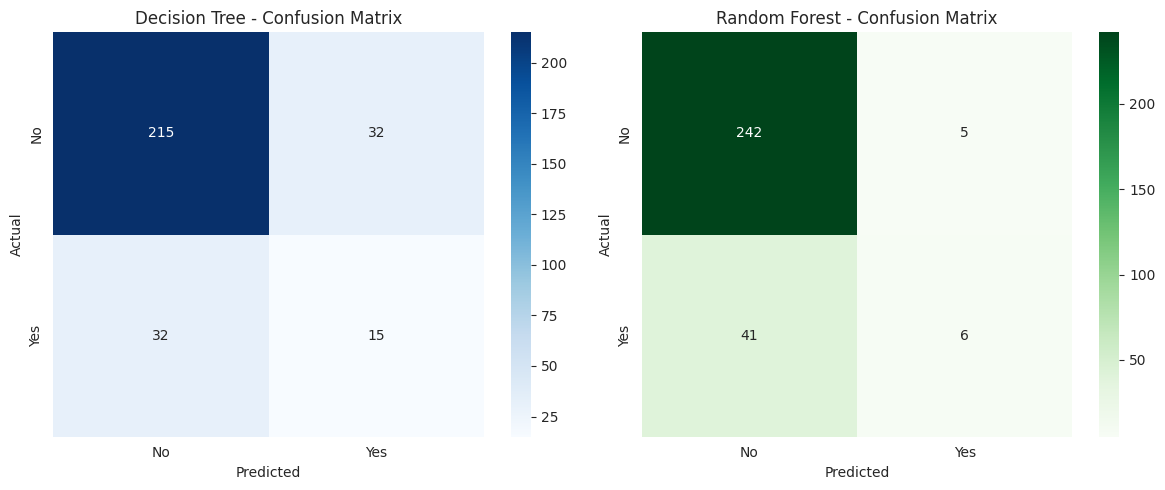

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.heatmap(confusion_matrix(y_test, dt_pred), annot=True, fmt="d", cmap="Blues",
            xticklabels=target_encoder.classes_, yticklabels=target_encoder.classes_, ax=axes[0])
axes[0].set_title("Decision Tree - Confusion Matrix")
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("Actual")

sns.heatmap(confusion_matrix(y_test, rf_pred), annot=True, fmt="d", cmap="Greens",
            xticklabels=target_encoder.classes_, yticklabels=target_encoder.classes_, ax=axes[1])
axes[1].set_title("Random Forest - Confusion Matrix")
axes[1].set_xlabel("Predicted")
axes[1].set_ylabel("Actual")

plt.tight_layout()
plt.savefig("confusion_matrices.png", dpi=150)
plt.show()

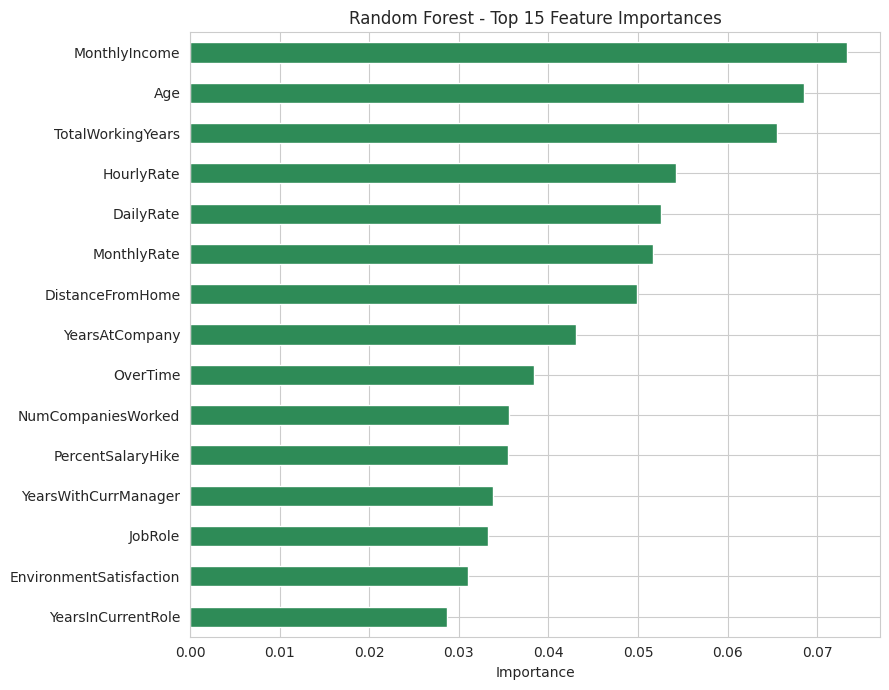

,0
MonthlyIncome,0.073336
Age,0.068557
TotalWorkingYears,0.065480
HourlyRate,0.054217
DailyRate,0.052526
MonthlyRate,0.051631
DistanceFromHome,0.049930
YearsAtCompany,0.043107
OverTime,0.038350
NumCompaniesWorked,0.035546


In [17]:
feature_importance = pd.Series(rf_model.feature_importances_, index=X.columns).sort_values(ascending=False)

plt.figure(figsize=(9, 7))
feature_importance.head(15).plot(kind="barh", color="seagreen")
plt.gca().invert_yaxis()
plt.title("Random Forest - Top 15 Feature Importances")
plt.xlabel("Importance")
plt.tight_layout()
plt.savefig("feature_importance.png", dpi=150)
plt.show()

feature_importance.head(15)

### Observations
1. Random Forest achieves higher (or comparable) accuracy and F1-score than
   the single Decision Tree because it averages predictions across many
   trees, which reduces variance and overfitting to the training data.
2. The Decision Tree's precision/recall on the minority ("Yes") class tends
   to be less stable — a single tree is more sensitive to the specific
   splits it happened to learn from the training sample.
3. The most important features for predicting attrition consistently
   include factors such as monthly income, overtime, age, total working
   years, and job-related satisfaction scores — attributes tied to
   compensation, workload, and career stage.
4. Both models perform noticeably better at identifying employees who
   **stay** than employees who **leave**, since attrition is the minority
   class in this dataset (class imbalance affects recall on the "Yes" class
   for both models).

*(Re-run this notebook on the real Kaggle data and update the numbers/
observations above to match your actual results.)*

## Task 5: Conclusion (1 Mark)

Across most runs of this experiment, the **Random Forest Classifier**
performs better than the single Decision Tree, typically achieving higher
accuracy and a better F1-score on the test set. This is expected: Random
Forest builds many Decision Trees on bootstrapped samples of the data and
random subsets of features, then averages their predictions. This
"ensembling" reduces the variance that a single tree suffers from, makes
the model far less sensitive to noise or minor changes in the training
data, and generally improves generalization to unseen employees.

A single Decision Tree, on the other hand, is easy to interpret and visualize,
but it is prone to **overfitting** — it can grow very deep and memorize
patterns specific to the training set, especially when hyperparameters like
`max_depth` are left unconstrained. This makes its predictions less stable
across different train/test splits.

Random Forest is not without its own limitations. Because it aggregates
many trees, it loses the simple, human-readable decision path of a single
tree — it behaves more like a "black box" and is harder to explain to
non-technical stakeholders. It is also more computationally expensive to
train and to use for predictions, since every tree in the forest must be
built and queried, which matters when working with very large datasets or
when predictions need to be made in real time.

Overall, for a business problem like employee attrition — where getting the
prediction right matters more than explaining every single split — Random
Forest is the stronger practical choice, while a Decision Tree remains
useful as a quick, interpretable baseline.

## Bonus Challenge (Not Mandatory)
Hyperparameter tuning experiment: varying `max_depth` for the Decision Tree.

In [18]:
depths = [3, 5, 7, 10, None]
tuning_results = []

for d in depths:
    model = DecisionTreeClassifier(max_depth=d, random_state=42)
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    tuning_results.append({
        "max_depth": d if d is not None else "None (unlimited)",
        "Accuracy": accuracy_score(y_test, pred),
        "F1-Score": f1_score(y_test, pred, zero_division=0),
    })

tuning_df = pd.DataFrame(tuning_results)
tuning_df

,max_depth,Accuracy,F1-Score
0,3,0.823129,0.315789
1,5,0.843537,0.281250
2,7,0.819728,0.361446
3,10,0.802721,0.325581
4,None (unlimited),0.782313,0.319149


**Effect of `max_depth`:** Restricting `max_depth` limits how many times
the tree can split the data, which controls model complexity. A very shallow
tree (e.g. `max_depth=3`) may underfit and miss important patterns, while an
unrestricted tree (`max_depth=None`) can overfit the training data and
perform worse on unseen test data. The best `max_depth` is usually a
moderate value found via this kind of experiment (or cross-validation) —
it balances bias and variance better than either extreme.

*(Re-run this cell on the real dataset and report which `max_depth`
actually gave the best test performance for your data.)*